删除之前的测试数据

In [15]:
import os
import pandas as pd

def delete_files_with_incorrect_episodes(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            try:
                data = pd.read_csv(file_path)
                num_of_episodes = data.loc[data['Parameter'] == 'num_of_episodes', 'Value'].values[0]
                total_timesteps = data.loc[data['Parameter'] == 'total_timesteps', 'Value'].values[0]
                
                if int(num_of_episodes) != 9 or int(total_timesteps)!=900000:
                    os.remove(file_path)
                    print(f"Deleted {file_path} because num_of_episodes is not 2.")
            except Exception as e:
                print(f"Error processing file {file_path}: {e}")

# Example usage:
folder_path = r'D:\trg1vr\sumo-rl-main\sumo-rl-main\results'  # Replace with your folder path
delete_files_with_incorrect_episodes(folder_path)


Error processing file D:\trg1vr\sumo-rl-main\sumo-rl-main\results\19-44-53-1502-result.csv: 'Parameter'
Error processing file D:\trg1vr\sumo-rl-main\sumo-rl-main\results\19-44-53-1601-result.csv: 'Parameter'
Error processing file D:\trg1vr\sumo-rl-main\sumo-rl-main\results\19-44-53-3457-result.csv: 'Parameter'


第一组对比是关于RL对于四，二阶段的提升效应；第二组对比是在共同使用RL的基础上，17-stage与4，2-stage的区别

In [16]:
import os
import pandas as pd
import re

def extract_saturation_value(proportion_of_saturations):
    match = re.search(r'\[([\d\.]+)', proportion_of_saturations)
    if match:
        return float(match.group(1))
    return None

def categorize_files(folder_path, target_saturations):
    categorized_files = {saturation: [None, None, None, None, None] for saturation in target_saturations}

    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            data = pd.read_csv(file_path)

            # Check if the required columns exist
            if 'Parameter' in data.columns and 'Value' in data.columns:
                proportion_of_saturations = data.loc[data['Parameter'] == 'proportion_of_saturations', 'Value'].values[0]
                saturation_value = extract_saturation_value(proportion_of_saturations)

                if saturation_value in target_saturations:
                    fix_ts = data.loc[data['Parameter'] == 'fix_ts', 'Value'].values[0] if 'fix_ts' in data['Parameter'].values else None
                    net_path = data.loc[data['Parameter'] == 'net_path', 'Value'].values[0] if 'net_path' in data['Parameter'].values else ''

                    if '-3' in net_path and fix_ts == 'False':
                        # two-stage, no fix_ts
                        categorized_files[saturation_value][0] = file_path
                    elif '-4' in net_path and fix_ts == 'False':
                        # four-stage, no fix_ts
                        categorized_files[saturation_value][1] = file_path
                    elif '-3' in net_path and fix_ts == 'True':
                        # two-stage, fix_ts
                        categorized_files[saturation_value][2] = file_path
                    elif '-4' in net_path and fix_ts == 'True':
                        # four-stage, fix_ts
                        categorized_files[saturation_value][3] = file_path
                    elif '-2' in net_path:
                        # 17-stage
                        categorized_files[saturation_value][4] = file_path

    return categorized_files

# Example usage:
folder_path = r'D:\trg1vr\sumo-rl-main\sumo-rl-main\results'  # Replace with your folder path
target_saturations = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
categorized_files = categorize_files(folder_path, target_saturations)

# Print the categorized files and their lengths
for saturation, files in categorized_files.items():
    print(f"Saturation {saturation}: {files}")
    print(f"Length of tuple for saturation {saturation}: {len(files)}")


Saturation 0.5: ['D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\21-09-18-2999-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\23-26-53-2300-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\18-12-08-6320-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\21-59-32-3251-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\23-44-22-1353-result.csv']
Length of tuple for saturation 0.5: 5
Saturation 0.55: ['D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\19-44-53-9540-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\05-48-32-9696-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\22-32-02-5744-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\08-27-48-9295-result.csv', 'D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\04-16-19-5334-result.csv']
Length of tuple for saturation 0.55: 5
Saturation 0.6: ['D:\\trg1vr\\sumo-rl-main\\sumo-rl-main\\results\\22-39-36-5826-result.csv', 'D:\\trg1vr\\sumo-rl-mai

第二步，绘制关于RL在2-stage,4-stage的提升作用

KeyError: 'Average_system_total_waiting_time'

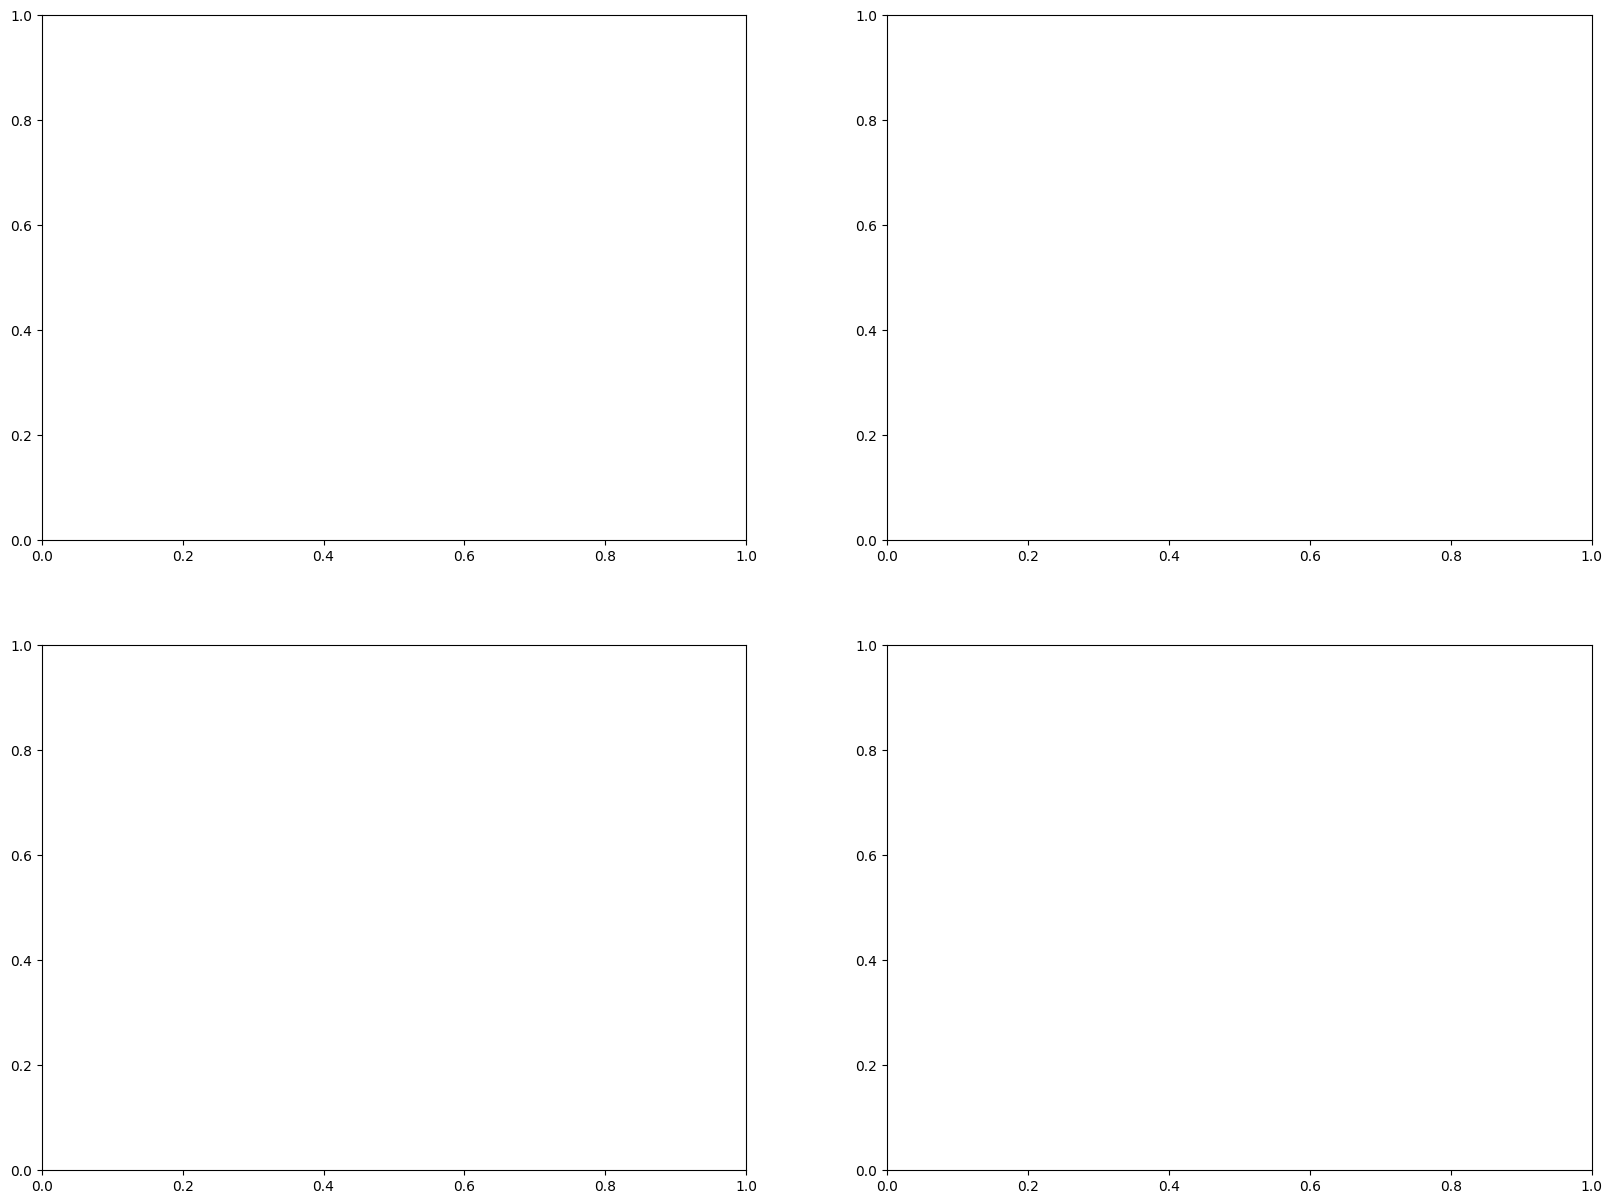

In [17]:
from matplotlib import pyplot as plt
import pandas as pd
import os

def plot_waiting_time_from_csv_list(file_paths_dict, saturation_value=None, ax=None):
    labels_dict = {
        'two-stage': 'DQN - two-stage',
        'four-stage': 'DQN - four-stage',
        '17-stage': 'DQN - 17-stage'
    }
    for stage, file_paths in file_paths_dict.items():
        max_waiting_time = -float('inf')
        min_waiting_time = float('inf')

        for idx, file_path in enumerate(file_paths):
            if file_path is not None:  # Check if the file_path is not None
                data = pd.read_csv(file_path)
                waiting_time_data = data[data['Parameter'].str.contains('Average system_Average_waiting_time for episode')]
                waiting_time_data['Episode'] = waiting_time_data['Parameter'].str.extract('(\d+)').astype(int)
                waiting_time_data['Average_system_Average_waiting_time'] = waiting_time_data['Value'].astype(float)
                waiting_time_data = waiting_time_data.sort_values('Episode')

                max_waiting_time = max(max_waiting_time, waiting_time_data['Average_system_total_waiting_time'].max())
                min_waiting_time = min(min_waiting_time, waiting_time_data['Average_system_total_waiting_time'].min())

                label = labels_dict[stage] if idx == 0 else None
                ax.plot(waiting_time_data['Episode'], waiting_time_data['Average_system_total_waiting_time'], marker='o', linestyle='-', label=label)

    ax.set_title(f'Saturation: {saturation_value}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Average system_total_waiting_time')
    ax.grid(True)
    ax.set_ylim(min_waiting_time - 50, max_waiting_time + 50)
    ax.legend()

# Ensure the directory exists
if not os.path.exists('rl-2-4-stage'):
    os.makedirs('rl-2-4-stage')

# Assuming categorized_files is defined and populated
categorized_files = categorize_files(folder_path, target_saturations)

# Plot groups of 4 subplots in one figure, each with three stages
saturation_keys = sorted(categorized_files.keys())
for i in range(0, len(saturation_keys), 4):
    fig, axs = plt.subplots(2, 2, figsize=(20, 15))
    
    for j in range(4):
        if i + j < len(saturation_keys):
            saturation = saturation_keys[i + j]
            file_list = categorized_files[saturation]
            if len(file_list) >= 5:
                file_paths_dict = {
                    'two-stage': [file_list[0], file_list[1]],
                    'four-stage': [file_list[1], file_list[4]],
                    '17-stage': [file_list[0], file_list[4]]
                }
                ax = axs[j//2, j%2]
                plot_waiting_time_from_csv_list(file_paths_dict, saturation_value=saturation, ax=ax)

    fig.tight_layout()
    fig.savefig(f'rl-2-4-stage/combined_plot_{i//4 + 1}.png')
    plt.close(fig)


新的数据结构，里面包含了第8和9 episode的平均值

In [ ]:
import pandas as pd

def get_average_waiting_time(file_path):
    if file_path is None:
        return None

    data = pd.read_csv(file_path)
    
    episodes = ['Average system_total_waiting_time for episode 8', 
                'Average system_total_waiting_time for episode 9', 
                'Average system_total_waiting_time for episode 10', 
                'Average system_total_waiting_time for episode 11', 
                'Average system_total_waiting_time for episode 12']

    waiting_times = []

    for episode in episodes:
        value = data.loc[data['Parameter'] == episode, 'Value']
        if not value.empty:
            waiting_times.append(float(value.values[0]))

    if len(waiting_times) >= 2:
        avg_waiting_time = sum(waiting_times[-2:]) / 2
        return avg_waiting_time
    else:
        return None

def get_overall_average_stopped(file_path):
    if file_path is None:
        return None

    data = pd.read_csv(file_path)
    
    value = data.loc[data['Parameter'] == 'Overall Average system_total_stopped', 'Value']
    if not value.empty:
        return float(value.values[0])
    else:
        return None

def get_overall_mean_waiting_time(file_path):
    if file_path is None:
        return None

    data = pd.read_csv(file_path)
    
    value = data.loc[data['Parameter'] == 'Overall Average system_mean_waiting_time', 'Value']
    if not value.empty:
        return float(value.values[0])
    else:
        return None

def process_categorized_files(categorized_files, func):
    new_categorized_files = {}
    
    for saturation, file_paths in categorized_files.items():
        new_values = tuple(func(fp) for fp in file_paths)
        new_categorized_files[saturation] = new_values
    
    return new_categorized_files

def remove_outlier(data_structure, outlier_value):
    cleaned_data_structure = {}
    for saturation, values in data_structure.items():
        cleaned_values = tuple(value if value != outlier_value else None for value in values)
        cleaned_data_structure[saturation] = cleaned_values
    return cleaned_data_structure

# Process files to get average waiting times
new_categorized_waiting_times = process_categorized_files(categorized_files, get_average_waiting_time)
# Process files to get overall average stopped
new_categorized_stopped = process_categorized_files(categorized_files, get_overall_average_stopped)
# Process files to get overall mean waiting time
new_categorized_mean_waiting_time = process_categorized_files(categorized_files, get_overall_mean_waiting_time)

# Remove outliers
outlier_value = 2994.91
new_categorized_mean_waiting_time = remove_outlier(new_categorized_mean_waiting_time, outlier_value)

# Print the new categorized files with average waiting times
print("New Categorized Waiting Times:")
for saturation, values in new_categorized_waiting_times.items():
    print(f"Saturation {saturation}: {values}")
    print(f"Length of tuple for saturation {saturation}: {len(values)}")

# Print the new categorized files with overall average stopped
print("\nNew Categorized Overall Average Stopped:")
for saturation, values in new_categorized_stopped.items():
    print(f"Saturation {saturation}: {values}")
    print(f"Length of tuple for saturation {saturation}: {len(values)}")

# Print the new categorized files with overall mean waiting time
print("\nNew Categorized Overall Mean Waiting Time:")
for saturation, values in new_categorized_mean_waiting_time.items():
    print(f"Saturation {saturation}: {values}")
    print(f"Length of tuple for saturation {saturation}: {len(values)}")

New Categorized Waiting Times:
Saturation 0.5: (None, None, None, None, None)
Length of tuple for saturation 0.5: 5
Saturation 0.55: (None, None, None, None, None)
Length of tuple for saturation 0.55: 5
Saturation 0.6: (None, None, None, None, None)
Length of tuple for saturation 0.6: 5
Saturation 0.65: (None, None, None, None, None)
Length of tuple for saturation 0.65: 5
Saturation 0.7: (None, None, None, None, None)
Length of tuple for saturation 0.7: 5
Saturation 0.75: (None, None, None, None, None)
Length of tuple for saturation 0.75: 5
Saturation 0.8: (None, None, None, None, None)
Length of tuple for saturation 0.8: 5
Saturation 0.85: (None, None, None, None, None)
Length of tuple for saturation 0.85: 5

New Categorized Overall Average Stopped:
Saturation 0.5: (7.304, 15.982, None, None, 12.907)
Length of tuple for saturation 0.5: 5
Saturation 0.55: (9.844, 19.207, None, None, 12.242)
Length of tuple for saturation 0.55: 5
Saturation 0.6: (19.592, 23.09, None, None, 83.267)
Lengt

创建反应整体情况的图


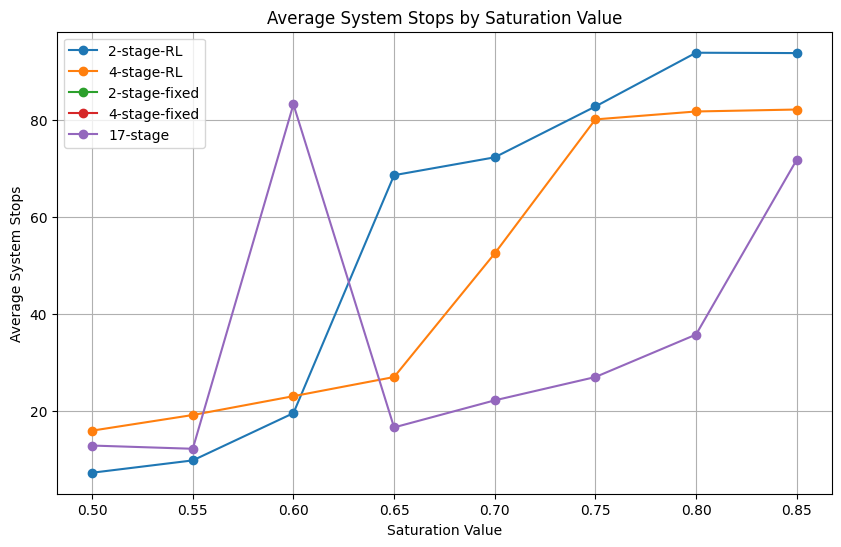

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_average_waiting_times(categorized_files):
    labels = ['2-stage-RL', '4-stage-RL', '2-stage-fixed', '4-stage-fixed', '17-stage']
    saturation_values = sorted(categorized_files.keys())
    
    # Initialize a plot
    plt.figure(figsize=(10, 6))
    
    for i, label in enumerate(labels):
        y_values = [categorized_files[sat][i] if categorized_files[sat][i] is not None else np.nan for sat in saturation_values]
        plt.plot(saturation_values, y_values, marker='o', linestyle='-', label=label)
    
    plt.title('Average System Stops by Saturation Value')
    plt.xlabel('Saturation Value')
    plt.ylabel('Average System Stops')
    plt.grid(True)
    plt.legend()
    # Save the plot to the current directory
    plt.savefig(f'Stops.png')
    plt.show()

plot_average_waiting_times(new_categorized_stopped)


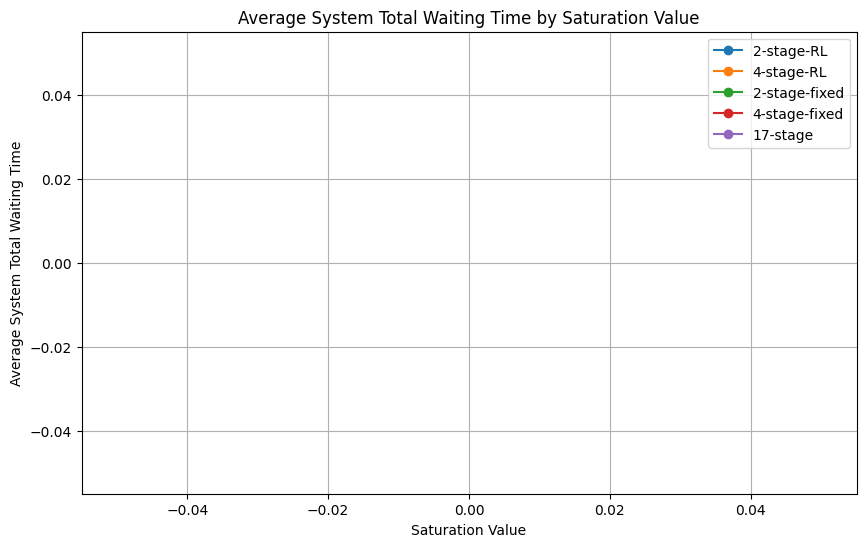

In [ ]:
from matplotlib.pyplot import plot


plot_average_waiting_times(new_categorized_files_for_stop)